In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

train_path = "/content/drive/MyDrive/Thesis_UNSW_NB15/UNSW_NB15_training-set.csv"
test_path  = "/content/drive/MyDrive/Thesis_UNSW_NB15/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("Train label %:\n", train_df["label"].value_counts(normalize=True))
print("Test label %:\n", test_df["label"].value_counts(normalize=True))

Mounted at /content/drive
Train shape: (175341, 45)
Test shape : (82332, 45)
Train label %:
 label
1    0.680622
0    0.319378
Name: proportion, dtype: float64
Test label %:
 label
1    0.5506
0    0.4494
Name: proportion, dtype: float64


#preprossing

In [ ]:
qos_features = [
    "dur",
    "spkts","dpkts",
    "sbytes","dbytes",
    "rate",
    "sload","dload",
    "sloss","dloss",
    "sjit","djit",
    "tcprtt","synack","ackdat",
    "ct_srv_src",
    "ct_dst_ltm",
    "ct_src_ltm",
    "ct_srv_dst"
]


qos_features = [c for c in qos_features if c in train_df.columns]

print("QoS features:", len(qos_features))
print(qos_features)

X_train = train_df[qos_features].copy()
X_test  = test_df[qos_features].copy()

y_train = train_df["label"].astype(int).values
y_test  = test_df["label"].astype(int).values

print(X_train.shape, X_test.shape)

QoS features: 19
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'ct_srv_src', 'ct_dst_ltm', 'ct_src_ltm', 'ct_srv_dst']
(175341, 19) (82332, 19)


#Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_train_nn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_test_nn  = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

#reshape for CNN/LSTM/Hybrid

In [ ]:
import numpy as np

X_train_nn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_test_nn  = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

print("NN shapes:", X_train_nn.shape, X_test_nn.shape)

NN shapes: (175341, 19, 1) (82332, 19, 1)


# Prepare data for unsupervised learning

In [ ]:


import numpy as np


print("Train label distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts())


X_train_normal = X_train_s[y_train == 0]

print("\nOriginal training set shape:", X_train_s.shape)
print("Normal-only training set shape:", X_train_normal.shape)



print("\nExample of first normal sample:")
print(X_train_normal[0])

print("\nTotal normal samples used for unsupervised training:", len(X_train_normal))

Train label distribution:
1    119341
0     56000
Name: count, dtype: int64

Test label distribution:
1    45332
0    37000
Name: count, dtype: int64

Original training set shape: (175341, 19)
Normal-only training set shape: (56000, 19)

Example of first normal sample:
[-0.19102881 -0.10445581 -0.1357688  -0.04913362 -0.10272556 -0.57637127
 -0.38989743 -0.27369954 -0.07503992 -0.13175867 -0.10999661 -0.1459046
 -0.52165962 -0.48434597 -0.5030137  -0.77599064 -0.64501291 -0.71571366
 -0.75307402]

Total normal samples used for unsupervised training: 56000


#training utilities (class_weight + callbacks)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

classes = np.array([0,1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {0: cw[0], 1: cw[1]}
print("class_weight:", class_weight)

early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
lr_plateau = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1)

class_weight: {0: np.float64(1.565544642857143), 1: np.float64(0.734621798040908)}


#Evaluation function

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

def eval_model(model, X, y, name="Model"):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= 0.65).astype(int)

    print(f"\n===== {name} =====")
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
    print("\nClassification Report:\n", classification_report(y, y_pred, digits=4))
    print("Accuracy:", accuracy_score(y, y_pred))
    print("ROC-AUC:", roc_auc_score(y, y_prob))

    rep = classification_report(y, y_pred, output_dict=True)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "ROC_AUC": roc_auc_score(y, y_prob),
        "Precision_attack": rep["1"]["precision"],
        "Recall_attack": rep["1"]["recall"],
        "F1_attack": rep["1"]["f1-score"],
        "Precision_normal": rep["0"]["precision"],
        "Recall_normal": rep["0"]["recall"],
        "F1_normal": rep["0"]["f1-score"],
    }

#CNN

In [ ]:


import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)


cnn_qos = models.Sequential([

    layers.Input(shape=(X_train_nn.shape[1], 1)),


    layers.Conv1D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling1D(2),


    layers.Conv1D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling1D(2),


    layers.Conv1D(256, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalAveragePooling1D(),


    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")

])

cnn_qos.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_qos.summary()



early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lr_plateau = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)



history = cnn_qos.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, lr_plateau],
    verbose=1
)



cnn_res = eval_model(cnn_qos, X_test_nn, y_test, "CNN (QoS)")
cnn_res

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,529 (650.50 KB)

 Trainable params: 165,633 (647.00 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.8849 - loss: 0.2439 - val_accuracy: 0.9687 - val_loss: 0.0877 - learning_rate: 0.0010
Epoch 2/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.8968 - loss: 0.2105 - val_accuracy: 0.9577 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 3/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9007 - loss: 0.2003 - val_accuracy: 0.9759 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 4/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.9029 - loss: 0.1933 - val_accuracy: 0.9452 - val_loss: 0.0919 - learning_rate: 0.0010
Epoch 5/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9054 - loss: 0.1883 - val_accuracy: 0.9714 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 6/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - accuracy: 0.9067 - loss: 0.1827 - val_accuracy: 0.9569 - val_loss: 0.0736 - learning_rate: 0.0010
Epoch 7/40
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9076 - lo

{'Model': 'CNN (QoS)',
 'Accuracy': 0.8728440946412087,
 'ROC_AUC': np.float64(0.9538949015193612),
 'Precision_attack': 0.8813915326550705,
 'Recall_attack': 0.8886437836406953,
 'F1_attack': 0.8850028010589102,
 'Precision_normal': 0.8621781745706719,
 'Recall_normal': 0.8534864864864865,
 'F1_normal': 0.8578103141510587}

#LSTM

In [ ]:


import tensorflow as tf
from tensorflow.keras import layers, Sequential

tf.random.set_seed(42)

lstm = Sequential([
    layers.Input(shape=(X_train_nn.shape[1], 1)),


    layers.Dense(64),


    layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.1
        )
    ),


    layers.LSTM(
        64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.1
    ),


    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

lstm.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.0007,
        weight_decay=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm.summary()
lstm.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, lr_plateau],
    verbose=1
)

lstm_res = eval_model(lstm, X_test_nn, y_test, "LSTM (QoS)")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 19, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 19, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,089 (1.13 MB)

 Trainable params: 296,833 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 250s 431ms/step - accuracy: 0.7857 - loss: 0.4314 - val_accuracy: 0.9239 - val_loss: 0.1861 - learning_rate: 7.0000e-04
Epoch 2/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8869 - loss: 0.2693
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
548/548 ━━━━━━━━━━━━━━━━━━━━ 245s 447ms/step - accuracy: 0.8907 - loss: 0.2576 - val_accuracy: 0.9366 - val_loss: 0.1362 - learning_rate: 7.0000e-04
Epoch 3/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 243s 444ms/step - accuracy: 0.8970 - loss: 0.2249 - val_accuracy: 0.9405 - val_loss: 0.1340 - learning_rate: 3.5000e-04
Epoch 4/40
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8976 - loss: 0.2188
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.
548/548 ━━━━━━━━━━━━━━━━━━━━ 237s 432ms/step - accuracy: 0.8992 - loss: 0.2154 - val_accuracy: 0.9085 - val_loss: 0.1734 - learning_rate: 3.5000e-04

===== LSTM (QoS) =====
Confusion Matrix:
 [[33384  3

#Hybrid CNN-LSTM
keeping the feature sequence after CNN, then uses LSTM to model it.

In [ ]:
tf.random.set_seed(42)

hybrid = Sequential([
    layers.Input(shape=(X_train_nn.shape[1], 1)),
    layers.Conv1D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling1D(2),
    layers.LSTM(64),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

hybrid.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="binary_crossentropy",
               metrics=["accuracy"])

hybrid.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, lr_plateau],
    verbose=1
)

hybrid_res = eval_model(hybrid, X_test_nn, y_test, "CNN-LSTM (QoS)")

Epoch 1/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.8566 - loss: 0.2979 - val_accuracy: 0.9737 - val_loss: 0.1075 - learning_rate: 0.0010
Epoch 2/30
547/548 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8921 - loss: 0.2288
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
548/548 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8930 - loss: 0.2238 - val_accuracy: 0.9690 - val_loss: 0.0761 - learning_rate: 0.0010
Epoch 3/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.8963 - loss: 0.2102 - val_accuracy: 0.9686 - val_loss: 0.0713 - learning_rate: 5.0000e-04
Epoch 4/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8957 - loss: 0.2091
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
548/548 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.8966 - loss: 0.2071 - val_accuracy: 0.9638 - val_loss: 0.0778 - learning_rate: 5.0000e-04

===== CNN-LSTM (QoS) =====
Confusion Matrix:
 [[32594  4406]
 [ 9394 35

#Transformer
Usinh the scaled tabular input (no reshape), each feature becomes a “token”

In [ ]:
from tensorflow.keras import Model

def build_tabular_transformer(num_features, d_model=64, num_heads=4, ff_dim=128, num_blocks=2, dropout=0.2):
    inputs = layers.Input(shape=(num_features,), name="features")
    x = layers.Reshape((num_features, 1))(inputs)
    x = layers.Dense(d_model)(x)

    for _ in range(num_blocks):
        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout)(x_norm, x_norm)
        attn = layers.Dropout(dropout)(attn)
        x = layers.Add()([x, attn])

        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        ff = layers.Dense(ff_dim, activation="relu")(x_norm)
        ff = layers.Dropout(dropout)(ff)
        ff = layers.Dense(d_model)(ff)
        ff = layers.Dropout(dropout)(ff)
        x = layers.Add()([x, ff])

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs, name="TabularTransformer")

tf.random.set_seed(42)

transformer = build_tabular_transformer(num_features=X_train_s.shape[1],
                                        d_model=64, num_heads=4, ff_dim=128,
                                        num_blocks=2, dropout=0.2)

transformer.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transformer.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, lr_plateau],
    verbose=1
)

tr_res = eval_model(transformer, X_test_s, y_test, "Transformer (QoS)")

Epoch 1/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 236s 413ms/step - accuracy: 0.7679 - loss: 0.4920 - val_accuracy: 0.9256 - val_loss: 0.2684 - learning_rate: 0.0010
Epoch 2/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.8074 - loss: 0.4369
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
548/548 ━━━━━━━━━━━━━━━━━━━━ 225s 410ms/step - accuracy: 0.8127 - loss: 0.4279 - val_accuracy: 0.9284 - val_loss: 0.2506 - learning_rate: 0.0010
Epoch 3/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 224s 410ms/step - accuracy: 0.8268 - loss: 0.3984 - val_accuracy: 0.9387 - val_loss: 0.1917 - learning_rate: 5.0000e-04
Epoch 4/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8248 - loss: 0.3940
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
548/548 ━━━━━━━━━━━━━━━━━━━━ 263s 412ms/step - accuracy: 0.8289 - loss: 0.3861 - val_accuracy: 0.9232 - val_loss: 0.1966 - learning_rate: 5.0000e-04

===== Transformer (QoS) =====
Confusion Matrix:
 [[32624  437

# UNSUPERVISED AUTOENCODER

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score

tf.random.set_seed(42)
np.random.seed(42)

X_train_normal = X_train_s[y_train == 0]

print("Full train shape:", X_train_s.shape)
print("Normal-only train shape:", X_train_normal.shape)

input_dim = X_train_s.shape[1]

autoencoder = Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

ae_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_ae = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[ae_early_stop],
    verbose=1
)


X_train_normal_pred = autoencoder.predict(X_train_normal, verbose=0)
train_normal_error = np.mean(np.square(X_train_normal - X_train_normal_pred), axis=1)


threshold = np.percentile(train_normal_error, 95)
print("Threshold:", threshold)


X_test_pred = autoencoder.predict(X_test_s, verbose=0)
reconstruction_error = np.mean(np.square(X_test_s - X_test_pred), axis=1)


y_pred_ae = (reconstruction_error > threshold).astype(int)


print("\n===== Autoencoder (Unsupervised QoS) =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ae))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ae, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred_ae))
print("ROC-AUC:", roc_auc_score(y_test, reconstruction_error))


rep_ae = classification_report(y_test, y_pred_ae, output_dict=True)

ae_res = {
    "Model": "Autoencoder (QoS)",
    "Accuracy": accuracy_score(y_test, y_pred_ae),
    "ROC_AUC": roc_auc_score(y_test, reconstruction_error),
    "Precision_attack": rep_ae["1"]["precision"],
    "Recall_attack": rep_ae["1"]["recall"],
    "F1_attack": rep_ae["1"]["f1-score"],
    "Precision_normal": rep_ae["0"]["precision"],
    "Recall_normal": rep_ae["0"]["recall"],
    "F1_normal": rep_ae["0"]["f1-score"],
}



Full train shape: (175341, 19)
Normal-only train shape: (56000, 19)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,779 (30.39 KB)

 Trainable params: 7,779 (30.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2427 - val_loss: 0.4267
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0334 - val_loss: 0.1906
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0185 - val_loss: 0.1002
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0114 - val_loss: 0.0680
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0077 - val_loss: 0.0350
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - val_loss: 0.0185
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0045 - val_loss: 0.0132
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0039 - val_loss: 0.0113
Epoch 9/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - val_loss: 0.0105
Epoch 10/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0028 - val_loss: 0.0100
Epoch 11/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0027 - val_loss: 0.0094
Epoch 12/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

#comparison table

In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    cnn_res,
    lstm_res,
    hybrid_res,
    tr_res,
    ae_res
])

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy,ROC_AUC,Precision_attack,Recall_attack,F1_attack,Precision_normal,Recall_normal,F1_normal
0,CNN (QoS),0.872844,0.953895,0.881392,0.888644,0.885003,0.862178,0.853486,0.857810
2,CNN-LSTM (QoS),0.832386,0.924689,0.890789,0.792773,0.838928,0.776269,0.880919,0.825290
1,LSTM (QoS),0.785673,0.896530,0.896443,0.690506,0.780112,0.704096,0.902270,0.790959
3,Transformer (QoS),0.691250,0.813492,0.847335,0.535780,0.656468,0.607886,0.881730,0.719636
4,Autoencoder (QoS),0.646759,0.826369,0.849666,0.435498,0.575846,0.566983,0.905595,0.697358


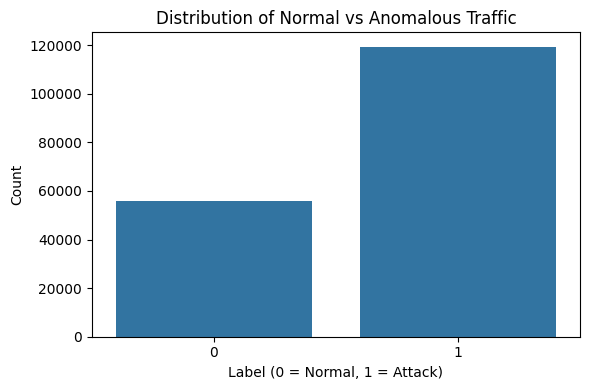

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=train_df["label"])

plt.title("Distribution of Normal vs Anomalous Traffic")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=300)
plt.show()

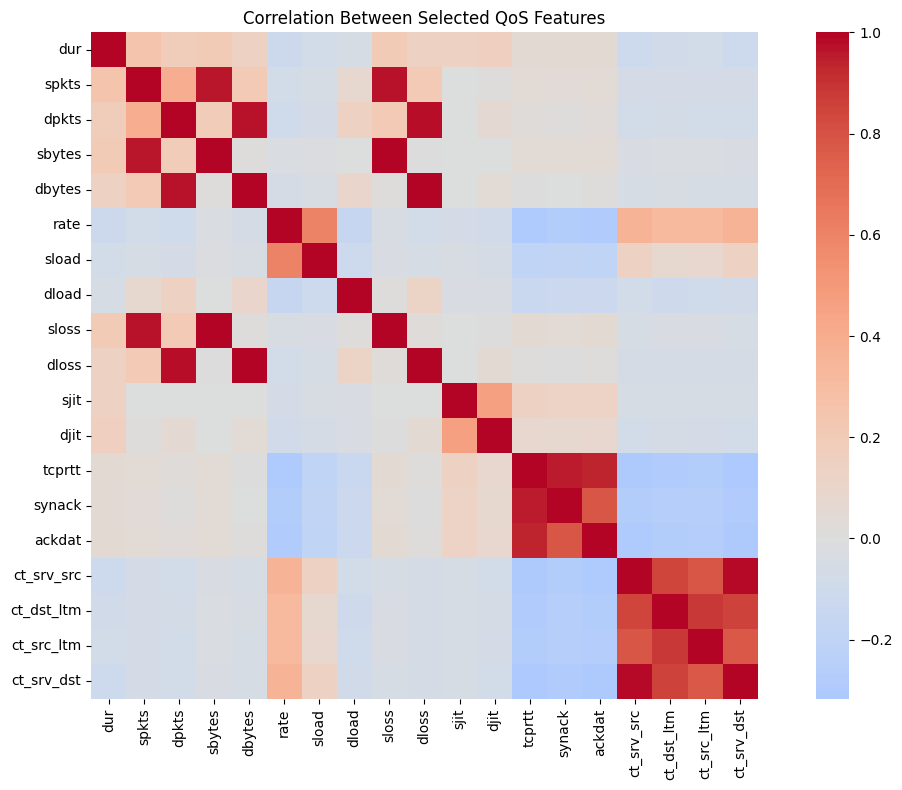

In [ ]:
plt.figure(figsize=(12,8))

corr = train_df[qos_features].corr()

sns.heatmap(corr,
            cmap="coolwarm",
            center=0,
            square=True)

plt.title("Correlation Between Selected QoS Features")

plt.tight_layout()
plt.savefig("qos_correlation.png", dpi=300)
plt.show()

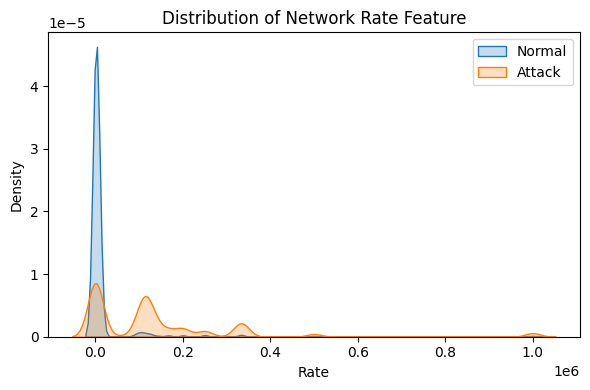

In [ ]:
plt.figure(figsize=(6,4))

sns.kdeplot(train_df[train_df["label"]==0]["rate"], label="Normal", fill=True)
sns.kdeplot(train_df[train_df["label"]==1]["rate"], label="Attack", fill=True)

plt.title("Distribution of Network Rate Feature")
plt.xlabel("Rate")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig("rate_distribution.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("qos_correlation.png")
files.download("rate_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

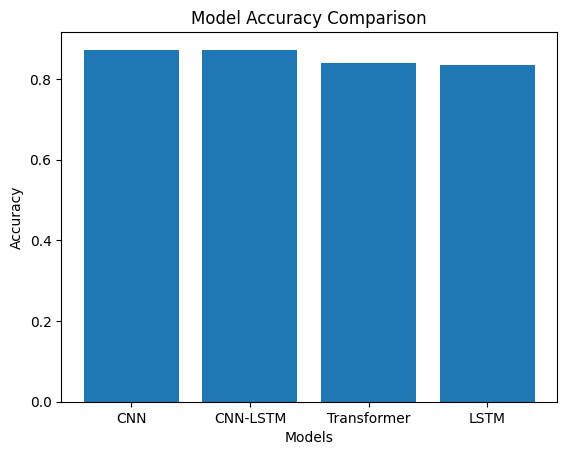

In [ ]:
import matplotlib.pyplot as plt

models = ['CNN', 'CNN-LSTM', 'Transformer', 'LSTM']

accuracy = [0.8728, 0.8723, 0.8391, 0.8339]
f1 = [0.8850, 0.8787, 0.8479, 0.8336]
roc_auc = [0.9539, 0.9468, 0.9217, 0.9261]

x = range(len(models))

plt.figure()
plt.bar(x, accuracy)
plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.savefig("accuracy_chart.png")
plt.show()

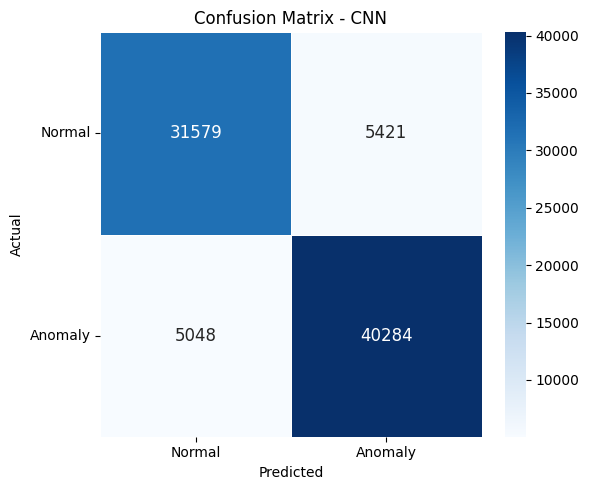

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


y_prob = cnn_qos.predict(X_test_nn, verbose=0).ravel()
y_pred = (y_prob >= 0.65).astype(int)


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=True,
            linewidths=0.5,
            linecolor='white',
            annot_kws={"size":12})

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN")

plt.xticks([0.5,1.5], ["Normal", "Anomaly"])
plt.yticks([0.5,1.5], ["Normal", "Anomaly"], rotation=0)

plt.tight_layout()
plt.savefig("cnn_confusion.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title, filename):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=True,
                linewidths=0.5,
                linecolor='white',
                annot_kws={"size":12, "weight":"bold"})

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.xticks([0.5,1.5], ["Normal", "Anomaly"])
    plt.yticks([0.5,1.5], ["Normal", "Anomaly"], rotation=0)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

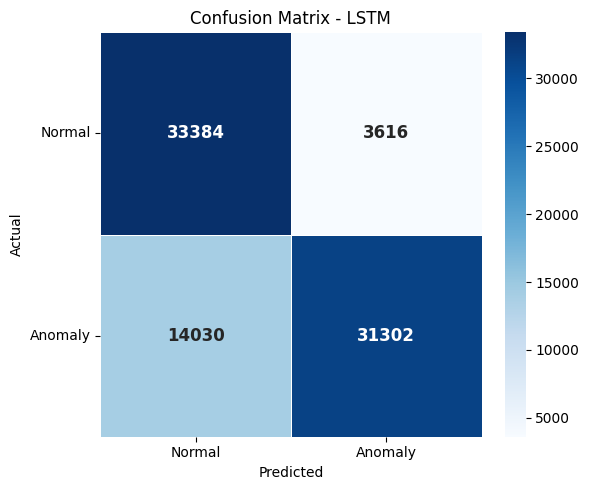

In [ ]:
y_prob = lstm.predict(X_test_nn, verbose=0).ravel()
y_pred = (y_prob >= 0.65).astype(int)

plot_confusion_matrix(y_test, y_pred,
                      "Confusion Matrix - LSTM",
                      "lstm_confusion.png")

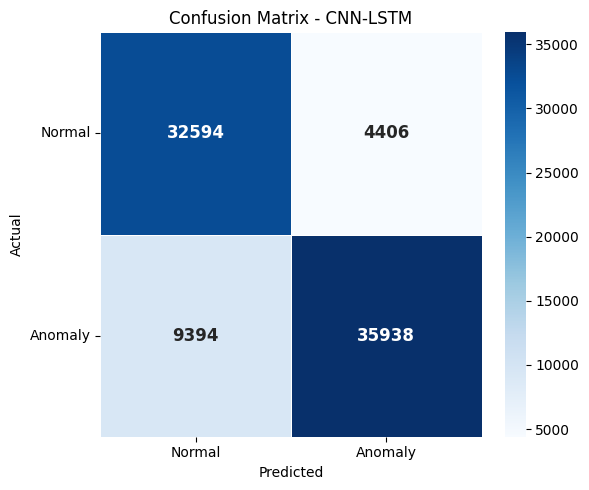

In [ ]:
y_prob = hybrid.predict(X_test_nn, verbose=0).ravel()
y_pred = (y_prob >= 0.65).astype(int)

plot_confusion_matrix(y_test, y_pred,
                      "Confusion Matrix - CNN-LSTM",
                      "cnn_lstm_confusion.png")

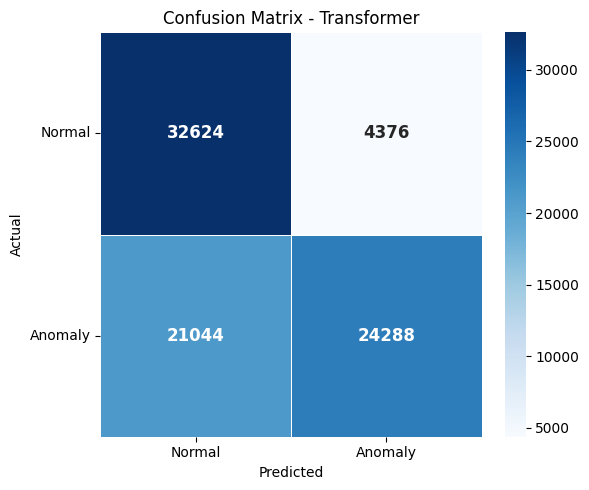

In [ ]:
y_prob = transformer.predict(X_test_s, verbose=0).ravel()
y_pred = (y_prob >= 0.65).astype(int)

plot_confusion_matrix(y_test, y_pred,
                      "Confusion Matrix - Transformer",
                      "transformer_confusion.png")

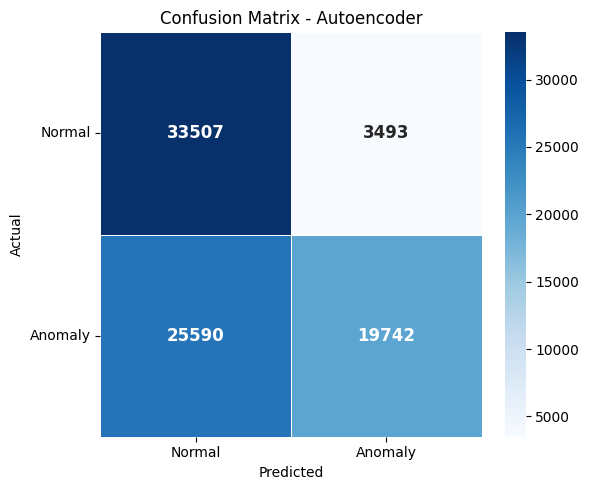

In [ ]:
plot_confusion_matrix(y_test, y_pred_ae,
                      "Confusion Matrix - Autoencoder",
                      "autoencoder_confusion.png")

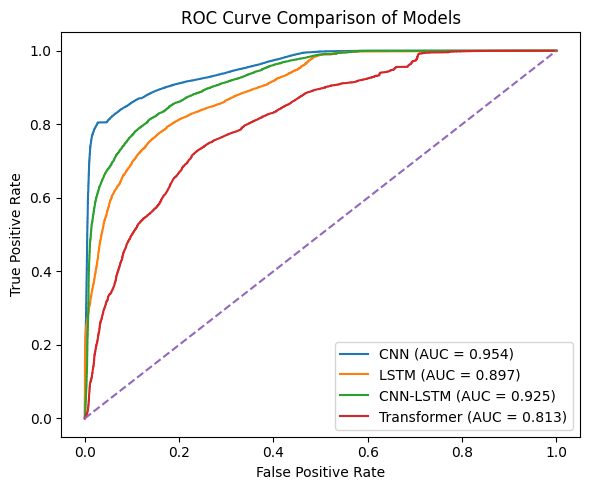

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))


y_prob_cnn = cnn_qos.predict(X_test_nn, verbose=0).ravel()
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC = {roc_auc_cnn:.3f})')


y_prob_lstm = lstm.predict(X_test_nn, verbose=0).ravel()
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {roc_auc_lstm:.3f})')


y_prob_hybrid = hybrid.predict(X_test_nn, verbose=0).ravel()
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test, y_prob_hybrid)
roc_auc_hybrid = auc(fpr_hybrid, tpr_hybrid)
plt.plot(fpr_hybrid, tpr_hybrid, label=f'CNN-LSTM (AUC = {roc_auc_hybrid:.3f})')


y_prob_tr = transformer.predict(X_test_s, verbose=0).ravel()
fpr_tr, tpr_tr, _ = roc_curve(y_test, y_prob_tr)
roc_auc_tr = auc(fpr_tr, tpr_tr)
plt.plot(fpr_tr, tpr_tr, label=f'Transformer (AUC = {roc_auc_tr:.3f})')




plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()

plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=300)
plt.show()